# Programación de árboles binarios

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

class TreePlotter:
    def __init__(self):
        self.graph = nx.DiGraph()
        self.pos = {}
        self.labels = {}
        self.node_count = 0

    def add_nodes_edges(self, node, parent=None, x=0, y=0, level_gap=1.5, sibling_gap=1.5):
        if node is None:
            return
        node_id = self.node_count
        self.node_count += 1

        label = getattr(node, 'nombre', getattr(node, 'titulo', getattr(node, 'pregunta', str(node))))
        self.graph.add_node(node_id)
        self.labels[node_id] = label
        self.pos[node_id] = (x, y)

        if parent is not None:
            self.graph.add_edge(parent, node_id)

        left = getattr(node, 'izquierda', None)
        right = getattr(node, 'derecha', None)

        if left:
            self.add_nodes_edges(left, node_id, x - sibling_gap, y - level_gap, level_gap, sibling_gap / 1.5)
        if right:
            self.add_nodes_edges(right, node_id, x + sibling_gap, y - level_gap, level_gap, sibling_gap / 1.5)

    def draw(self, root_node):
        self.graph.clear()
        self.pos.clear()
        self.labels.clear()
        self.node_count = 0
        self.add_nodes_edges(root_node)
        plt.figure(figsize=(12, 8))
        nx.draw(self.graph, pos=self.pos, labels=self.labels, with_labels=True, arrows=False,
                node_size=2000, node_color="lightblue", font_size=10, font_weight="bold")
        plt.title("Árbol Binario Visualizado")
        plt.axis("off")
        plt.show()


Declaración del nodo

In [ ]:
class Nodo:
    def __init__(self, dato):
        self.dato = dato
        self.izquierda = None
        self.derecha = None

Declaración del árbol

In [ ]:

class Arbol:

    def __init__(self, dato):
        self.raiz = Nodo(dato)

    def __agregar_recursivo(self, nodo, dato):
        if dato < nodo.dato:
            if nodo.izquierda is None:
                nodo.izquierda = Nodo(dato)
            else:
                self.__agregar_recursivo(nodo.izquierda, dato)
        else:
            if nodo.derecha is None:
                nodo.derecha = Nodo(dato)
            else:
                self.__agregar_recursivo(nodo.derecha, dato)

    def __inorden_recursivo(self, nodo):
        if nodo is not None:
            self.__inorden_recursivo(nodo.izquierda)
            print(nodo.dato, end=", ")
            self.__inorden_recursivo(nodo.derecha)

    def __preorden_recursivo(self, nodo):
        if nodo is not None:
            print(nodo.dato, end=", ")
            self.__preorden_recursivo(nodo.izquierda)
            self.__preorden_recursivo(nodo.derecha)

    def __postorden_recursivo(self, nodo):
        if nodo is not None:
            self.__postorden_recursivo(nodo.izquierda)
            self.__postorden_recursivo(nodo.derecha)
            print(nodo.dato, end=", ")

    def __buscar(self, nodo, busqueda):
        if nodo is None:
            return None
        if nodo.dato == busqueda:
            return nodo
        if busqueda < nodo.dato:
            return self.__buscar(nodo.izquierda, busqueda)
        else:
            return self.__buscar(nodo.derecha, busqueda)
        
    
                
    def __calcular_altura(self, nodo):
        if nodo is None:
            return 0
        altura_izquierda = self.__calcular_altura(nodo.izquierda)
        altura_derecha = self.__calcular_altura(nodo.derecha)
        return max(altura_izquierda, altura_derecha) + 1
    
    def altura(self):
        return self.__calcular_altura(self.raiz)
        



    def agregar(self, dato):
        self.__agregar_recursivo(self.raiz, dato)

    def inorden(self):
        print("Imprimiendo árbol inorden: ")
        self.__inorden_recursivo(self.raiz)
        print("")

    def preorden(self):
        print("Imprimiendo árbol preorden: ")
        self.__preorden_recursivo(self.raiz)
        print("")

    def postorden(self):
        print("Imprimiendo árbol postorden: ")
        self.__postorden_recursivo(self.raiz)
        print("")

    def buscar(self, busqueda):
        return self.__buscar(self.raiz, busqueda)

# Imprimir los elementos InOrden

In [ ]:
arbol_numeros = Arbol(27)
arbol_numeros.agregar(42)
arbol_numeros.agregar(13)
arbol_numeros.agregar(33)
arbol_numeros.agregar(17)
arbol_numeros.agregar(6)
arbol_numeros.agregar(48)

arbol_numeros.inorden()


# Imprimir los elementos preorden

In [ ]:
arbol_numeros = Arbol(27)
arbol_numeros.agregar(42)
arbol_numeros.agregar(13)
arbol_numeros.agregar(33)
arbol_numeros.agregar(17)
arbol_numeros.agregar(6)
arbol_numeros.agregar(48)

arbol_numeros.preorden()

# Imprimir los elementos postorden

In [ ]:
arbol_numeros = Arbol(27)
arbol_numeros.agregar(42)
arbol_numeros.agregar(13)
arbol_numeros.agregar(33)
arbol_numeros.agregar(17)
arbol_numeros.agregar(6)
arbol_numeros.agregar(48)

arbol_numeros.postorden()

# Buscar un elemento dentro del árbol

In [ ]:
arbol_numeros = Arbol(27)
arbol_numeros.agregar(42)
arbol_numeros.agregar(13)
arbol_numeros.agregar(33)
arbol_numeros.agregar(17)
arbol_numeros.agregar(6)
arbol_numeros.agregar(48)

busqueda = int(input("Ingresa un número para buscar en el árbol: "))
n = arbol_numeros.buscar(busqueda)
if n is None:
    print(f"{busqueda} no existe")
else:
    print(f"{busqueda} sí existe")

In [ ]:
arbol_numeros = Arbol(27)
arbol_numeros.agregar(42)
arbol_numeros.agregar(13)
arbol_numeros.agregar(33)
arbol_numeros.agregar(17)
arbol_numeros.agregar(6)
arbol_numeros.agregar(48)
print(arbol_numeros.altura())

Una plataforma de streaming desea implementar un sistema de recomendación de películas basado en dos criterios principales: la edad del usuario y su preferencia por películas de acción.

Se debe construir un árbol binario de decisión, donde cada nodo representa una pregunta de clasificación. El sistema tomará decisiones a la izquierda si la respuesta es negativa o a la derecha si es afirmativa. Las hojas del árbol contendrán una película recomendada.
Objetivo:

    Implementar un árbol binario de decisión.

    Simular preguntas y respuestas que conduzcan a una recomendación final.

    Evaluar recomendaciones con distintos valores de edad y gustos.

In [31]:
class NodoPelicula:
    def __init__(self, pregunta, izquierda=None, derecha=None):
        self.pregunta = pregunta
        self.izquierda = izquierda
        self.derecha = derecha
        
    def recomendar(self, edad, preferencia):
        if "edad" in self.pregunta:
           
            if edad < 18:
                return self.izquierda.recomendar(edad, preferencia) #MENOR DE EDAD
            else:
                return self.derecha.recomendar(edad, preferencia) #MAYOR DE EDAD
            
        elif "accion" in self.pregunta:
            if preferencia:
                return self.derecha.recomendar(edad, preferencia)
            else:
                return self.izquierda.recomendar(edad, preferencia)
            
        else:
            return self.pregunta
        
        
        
        
recom_1 =NodoPelicula("Recomendacion: Toy story 4")
recom_2 = NodoPelicula("Recomendacion: tontos y mas tontos 2")
recom_3 = NodoPelicula("Recomendacion: fast and furious 9")
            
nodo_accion = NodoPelicula("¿Te gustan las películas de accion?", recom_2, recom_3)
nodo_edad = NodoPelicula("eres mayor de edad?", recom_1, nodo_accion )

print("Bienvenido al recomendador de películas")
print(nodo_edad.recomendar(12, True))  # Cambia los parámetros según la edad y preferencia
print(nodo_edad.recomendar(20, True))  # Cambia los parámetros según la edad y preferencia
print(nodo_edad.recomendar(20, False))  # Cambia los parámetros según la edad y preferencia
print(nodo_edad.recomendar(16, True))  # Cambia los parámetros según la edad y preferencia
           


Bienvenido al recomendador de películas
Recomendacion: Toy story 4
Recomendacion: fast and furious 9
Recomendacion: tontos y mas tontos 2
Recomendacion: Toy story 4


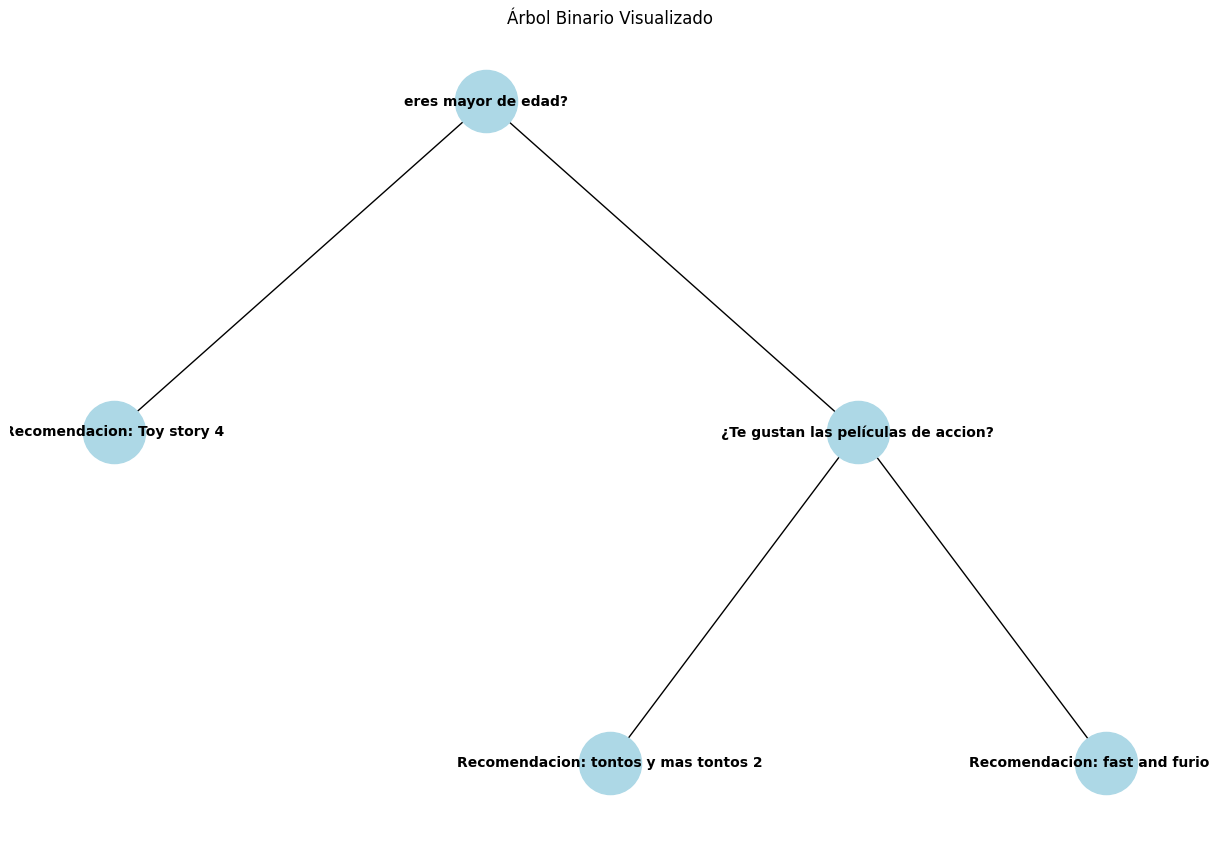

In [32]:
TreePlotter().draw(nodo_edad)

 Ejercicio 2: Agenda Telefónica Ordenada por Nombre
🧾 Enunciado Detallado:

Se debe implementar una agenda de contactos donde cada contacto tiene un nombre y un número de teléfono. Para optimizar la búsqueda por nombre, se utilizará un árbol binario de búsqueda (ABB), donde los nombres se insertan en orden alfabético.

El árbol debe permitir:

    Agregar contactos.

    Buscar un contacto por nombre.

    Retornar el número de teléfono correspondiente.

 Objetivo:

    Implementar inserción y búsqueda en un árbol binario de búsqueda.

    Aplicar comparación de cadenas para organizar nodos.

    Facilitar búsquedas rápidas por nombre.

In [35]:
class Contacto:
    def __init__ (self, nombre, telefono):
        self.nombre = nombre
        self.telefono = telefono
        self.izquierda = None
        self.derecha = None
        
    def insertar(self, nuevo):
        if nuevo.nombre < self.nombre:   # Roicardo  nuevo = jose  jose ricardo
            self.izquierda = self.izquierda.insertar(nuevo) if self.izquierda else nuevo
        else:
            self.derecha = self.derecha.insertar(nuevo) if self.derecha else nuevo
        return self
            
            
    def buscar(self, nombre):
        if nombre == self.nombre:
            return self.telefono
        elif nombre < self.nombre and self.izquierda:
            return self.izquierda.buscar(nombre) 
        elif nombre > self.nombre and self.derecha:
            return self.derecha.buscar(nombre)
        return "no encontrado"
    
agenda = Contacto("Juan", "123456789")
agenda = agenda.insertar(Contacto("Ana", "987654321"))
agenda = agenda.insertar(Contacto("Pedro", "456789123"))
agenda = agenda.insertar(Contacto("Maria", "321654987"))
agenda = agenda.insertar(Contacto("Zapata", "23546543"))

print(" telefono de juan: ", agenda.buscar("Juan"))
print(" telefono de Ana: ", agenda.buscar("Ana"))
print(" telefono de Pedro: ", agenda.buscar("Pedro"))
print(" telefono de mario: ", agenda.buscar("mario"))



 telefono de juan:  123456789
 telefono de Ana:  987654321
 telefono de Pedro:  456789123
 telefono de mario:  no encontrado


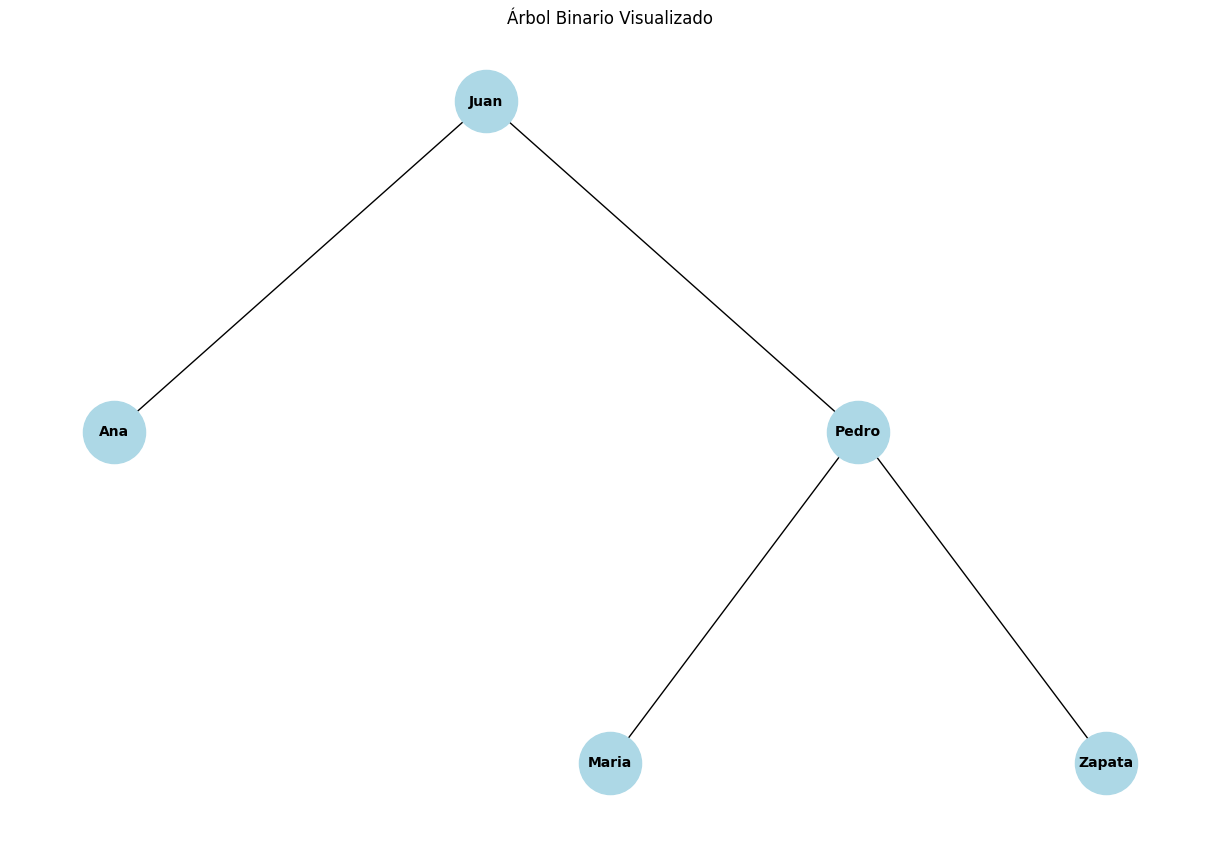

In [36]:
TreePlotter().draw(agenda)

Ejercicio 3: Clasificación de Productos por Precio
🧾 Enunciado Detallado:

Una tienda en línea desea desarrollar un sistema para clasificar productos según su precio de forma ascendente. Cada producto tiene un nombre y un precio.

El árbol binario deberá permitir:

    Insertar productos según su precio.

    Mostrar el catálogo en orden ascendente (inorden).

Este tipo de estructura es útil para sugerencias de productos similares o filtros por precio mínimo y máximo.
🎯 Objetivo:

    Construir un árbol binario basado en valores numéricos.

    Implementar una función de recorrido inorden para listar productos ordenadamente.

    Simular un catálogo dinámico.

Producto: Smartwatch, Precio: 300
Producto: Tablet, Precio: 600
Producto: Smartphone, Precio: 800
Producto: cccc, Precio: 900
Producto: Laptop, Precio: 1000
Producto: Televisor, Precio: 1200
Producto: Auriculares, Precio: 1500
Producto: Cámara, Precio: 1600


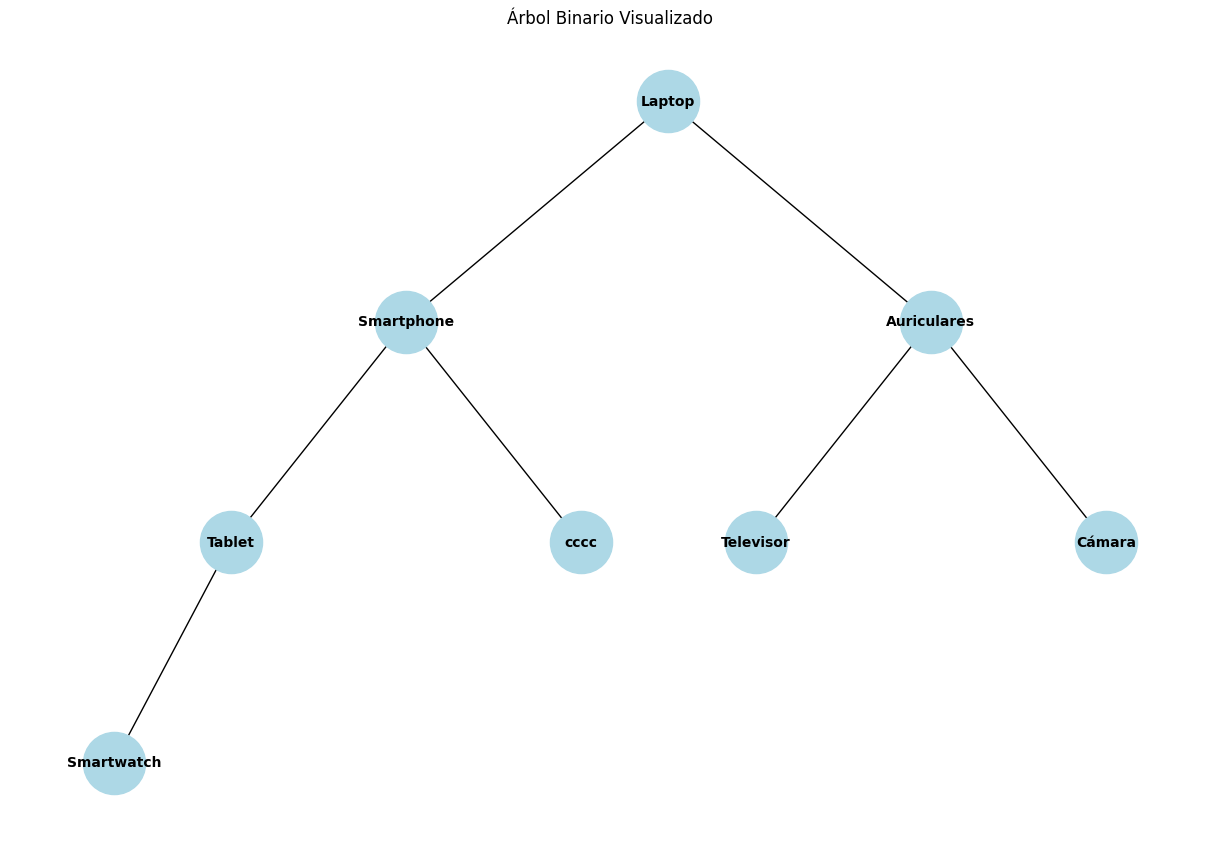

In [38]:
class Producto:
    def __init__(self, nombre, precio):
        self.nombre = nombre
        self.precio = precio
        self.izquierda = None
        self.derecha = None
        
    def insertar(self, nuevo):
        if nuevo.precio < self.precio:
            self.izquierda = self.izquierda.insertar(nuevo) if self.izquierda else nuevo
        else:
            self.derecha = self.derecha.insertar(nuevo) if self.derecha else nuevo
        return self
    
    def mostrar(self):
        
        if self.izquierda:
            self.izquierda.mostrar()
        
        print(f"Producto: {self.nombre}, Precio: {self.precio}")
        if self.derecha:
            self.derecha.mostrar()
        
 
    
productos = Producto("Laptop", 1000)
productos = productos.insertar(Producto("Smartphone", 800))
productos = productos.insertar(Producto("Tablet", 600))
productos = productos.insertar(Producto("Smartwatch", 300))
productos = productos.insertar(Producto("Auriculares", 1500))
productos = productos.insertar(Producto("Televisor", 1200))
productos = productos.insertar(Producto("Cámara", 1600))
productos = productos.insertar(Producto("cccc", 900))

productos.mostrar()
TreePlotter().draw(productos)


Ejercicio 4: Búsqueda de Libros por ISBN
🧾 Enunciado Detallado:

En una biblioteca universitaria se necesita un sistema para almacenar libros y consultarlos por su ISBN. Cada libro tiene un título y un ISBN único.

Se debe crear un árbol binario de búsqueda (ABB) donde cada nodo almacene un libro, y se pueda:

    Insertar libros ordenados por ISBN.

    Buscar rápidamente un libro usando su ISBN.

    Mostrar el título del libro si se encuentra.

Este sistema busca reducir el tiempo de búsqueda manual y mejorar la organización del inventario bibliográfico.
🎯 Objetivo:

    Implementar un ABB basado en un campo numérico clave (ISBN).

    Simular un sistema de gestión bibliotecaria básico.

    Mejorar tiempos de consulta en una colección de libros.